In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import sys
path = input('paste the url here ')
sheet_id = path.split('/d/')[1].split('/edit')[0]
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'
data = pd.read_csv(csv_url, skiprows=1)
today=pd.to_datetime('today').strftime('%d/%m/%Y')


paste the url here  https://docs.google.com/spreadsheets/d/1nxhT5HHzAPnSxYW0qv5P75RsN0u5Ow16CCDlxMcKMvs/edit?usp=sharing


In [2]:
def get_df(df):
  today=pd.to_datetime('today').strftime('%d-%m-%Y')
  df.columns=df.columns.str.lower().str.strip()
  if 'competition' in df.columns:
      df.set_index('competition', inplace=True)
  df = df[['date','start gmt', 'home', 'away','srt / rtmp url','igame channel','ingest method', 'sport']]
  df.sort_values(by=['start gmt'], inplace=True)
  df['start gmt'] = pd.to_datetime(df['start gmt']).dt.tz_localize('UTC').dt.tz_convert('Europe/London')
  df['date'] = pd.to_datetime(df['date'], format='mixed')
  df['srt / rtmp url'] = df['srt / rtmp url'].apply(lambda x: x.replace(x.split('srt')[1],\
                        ' link hidden') if 'srt' in x  else x)
  df.fillna('to be announed later', inplace=True)
  df1= df[df['date']==today]
  df1.to_csv(f'Booking Sheet for {today}.csv')
  return df1

def graphs(df, i, j='barh',t=None):
  Title=input('Enter Chart Title ')
  color=input('Enter Chart Color ')
  if i == 'competition':
    df.sort_values(by=['start gmt'], inplace=True)
    df.index.value_counts().plot(kind=j, color=color, figsize=(10,5), title=Title, fontsize=12)
  else:
    df[i].value_counts().plot(kind=j, color=color, figsize=(10,5), title=Title, fontsize=12)

In [3]:
get_df(data.copy())

,date,start gmt,home,away,srt / rtmp url,igame channel,ingest method,sport
competition,,,,,,,,


Enter Chart Title  Daily Sheet 
Enter Chart Color  c


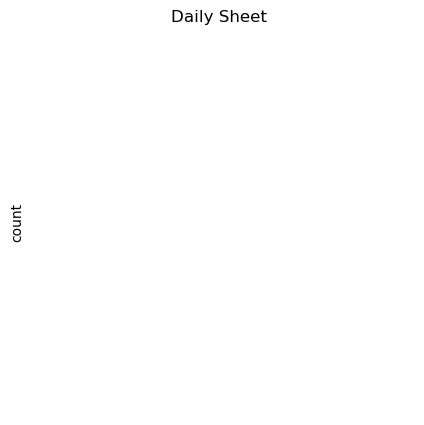

In [4]:
graphs(get_df(data),'sport', 'pie')